<a href="https://colab.research.google.com/github/deltorobarba/science/blob/main/quantum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue">**Quantum Computing**

In [ ]:
# IonQ libraries
!pip install cirq-ionq -q
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits
import json
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import files
from collections import Counter
import matplotlib.pyplot as plt
import cirq_ionq.ionq_exceptions as ionq_exceptions
from IPython.display import display, Markdown

In [2]:
# Connect to IonQ Service and Secret Manager for Token
from google.colab import userdata
api_token = userdata.get('ionq-quantum')
service = cirq_ionq.Service(api_key=api_token)
print("✅ Connection to IonQ successful")

# Check Available Backends (Simulators and QPUs)
print("\n✅ List of all backends (https://cloud.ionq.com/backends/qpus)")
headers = {"Authorization": f"apiKey {'ionq-quantum'}"}
r = requests.get("https://api.ionq.co/v0.3/backends", headers=headers)
if r.status_code == 200:
    available = [b for b in r.json() if b['status'].upper() == 'AVAILABLE']
    for i, b in enumerate(available, 1):
    #for i, b in enumerate(r.json(), 1): # to print all backends
        qt = b.get('average_queue_time', 0)
        print(f"\n{i}. {b['backend'].upper()}\n └── Type: {'QPU' if 'qpu' in b['backend'] else 'Simulator'}\n └── Status: {b['status'].upper()}\n └── Qubits: {b['qubits']}\n └── Average Queue Time: {f'{qt/3600:.1f} hours' if qt > 3600 else f'{qt/60:.1f} minutes' if qt > 60 else f'{qt} seconds'}" + (''.join([f"\n └── Available Noise Models: {', '.join(b['noise_models'])}" if 'noise_models' in b else "", f"\n └── Characterization: Available" if 'characterization_url' in b else "", f"\n └── DEGRADED SERVICE" if b.get('degraded', False) else ""])))
else: print(f"Backend check failed: {r.status_code}\nError details: {r.text}")


BACKEND = "qpu.forte-1" # forte-1, forte-enterprise-1, aria-1
print(f"\n✅ Selected backend: {BACKEND}")

# https://quantumai.google/cirq/hardware/ionq/calibrations - Error: Insufficient Scope
#calibration = service.get_current_calibration()
#print(calibration.fidelities())
#print(calibration.timings())

✅ Connection to IonQ successful

✅ List of all backends (https://cloud.ionq.com/backends/qpus)

1. QPU.FORTE-1
 └── Type: QPU
 └── Status: AVAILABLE
 └── Qubits: 36
 └── Average Queue Time: 3222.9 hours
 └── Characterization: Available

2. SIMULATOR
 └── Type: Simulator
 └── Status: AVAILABLE
 └── Qubits: 29
 └── Average Queue Time: 0 seconds
 └── Available Noise Models: aria-1, forte-1, forte-enterprise-1, ideal

3. QPU.FORTE-ENTERPRISE-1
 └── Type: QPU
 └── Status: AVAILABLE
 └── Qubits: 36
 └── Average Queue Time: 1908.5 hours
 └── Characterization: Available

✅ Selected backend: qpu.forte-1


In [3]:
# IonQ Circuit and Transpilation

print("\n✅ Quantum Circuit and Transpilation")
display(Markdown(r"Two-Qubit maximally entangled [Bell State](https://en.wikipedia.org/wiki/Bell_state) preparation $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ with each outcomes $|00\rangle$ and $|11\rangle$ at 50% probability."))
q0, q1 = cirq.LineQubit.range(2)
circuit = cirq.Circuit(
    cirq.H(q0),
    cirq.CNOT(q0, q1),
    cirq.measure(q0, q1, key='x'))
print(circuit)


✅ Quantum Circuit and Transpilation


Two-Qubit maximally entangled [Bell State](https://en.wikipedia.org/wiki/Bell_state) preparation $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ with each outcomes $|00\rangle$ and $|11\rangle$ at 50% probability.

0: ───H───@───M('x')───
          │   │
1: ───────X───M────────


In [4]:
# IonQ Simulation

print("\n✅ Noiseless simulation")
result = service.run(
    circuit=circuit,
    target="simulator",
    repetitions=100,
    name="Noiseless Cirq Simulation")
print(result.histogram(key='x'))
print(result)
with open('noiseless_result.pkl', 'wb') as f:
    pickle.dump(result, f)

print("\n✅ Noisy simulation")
# https://docs.ionq.com/guides/simulation-with-noise-models
result = service.run(
    circuit=circuit,
    target="simulator",
    repetitions=100,
    name="Noisy Cirq Simulation",
    extra_query_params={"noise": {"model": "forte-1"}})
print(result.histogram(key='x'))
print(result)
with open('noisy_result.pkl', 'wb') as f:
    pickle.dump(result, f)


✅ Noiseless simulation
Counter({0: 56, 3: 44})
x=1001010110001000010010000101011110101101100001110101101011000010000100101000111101010000000110101101, 1001010110001000010010000101011110101101100001110101101011000010000100101000111101010000000110101101

✅ Noisy simulation
Counter({3: 55, 0: 42, 1: 2, 2: 1})
x=1001101110010101001001000111111100111111110101010111011010110110110011101100010100000111010100111000, 1001101110011101001001000111111100111111110101010111011010110110110011001100010100010111010100111000


In [5]:
# IonQ Quantum Computation ⚠️

print("\n✅ Quantum simulation")
# (https://docs.ionq.com/guides/qpu-submission-checklist)
job = service.create_job(
    circuit=circuit,
    target=BACKEND,
    repetitions=100,
    name="QPU Cirq Simulation")
print(job.job_id())
print(job.status())

# Retrieve a job
#job_id = "019a7d6c-a0fb-779b-9340-8795a9a2f1c0"
#job = service.get_job(job_id)

# Get the first result from the list -  https://cloud.ionq.com/jobs
results_list = job.results()
result = results_list[0].to_cirq_result()  # Access first element
print(result.histogram(key='x'))
# Save results into file
with open('quantum_result.pkl', 'wb') as f:
    pickle.dump(result, f)


✅ Quantum simulation
019dcb89-89b9-775e-8af0-d4d49bab8474
submitted
Counter({3: 52, 0: 47, 1: 1})



✅ Comparison and Plotting of Results
 State Binary  Noiseless  Noisy  Quantum
     0     00         56     42       47
     1     01          0      2        1
     2     10          0      1        0
     3     11         44     55       52



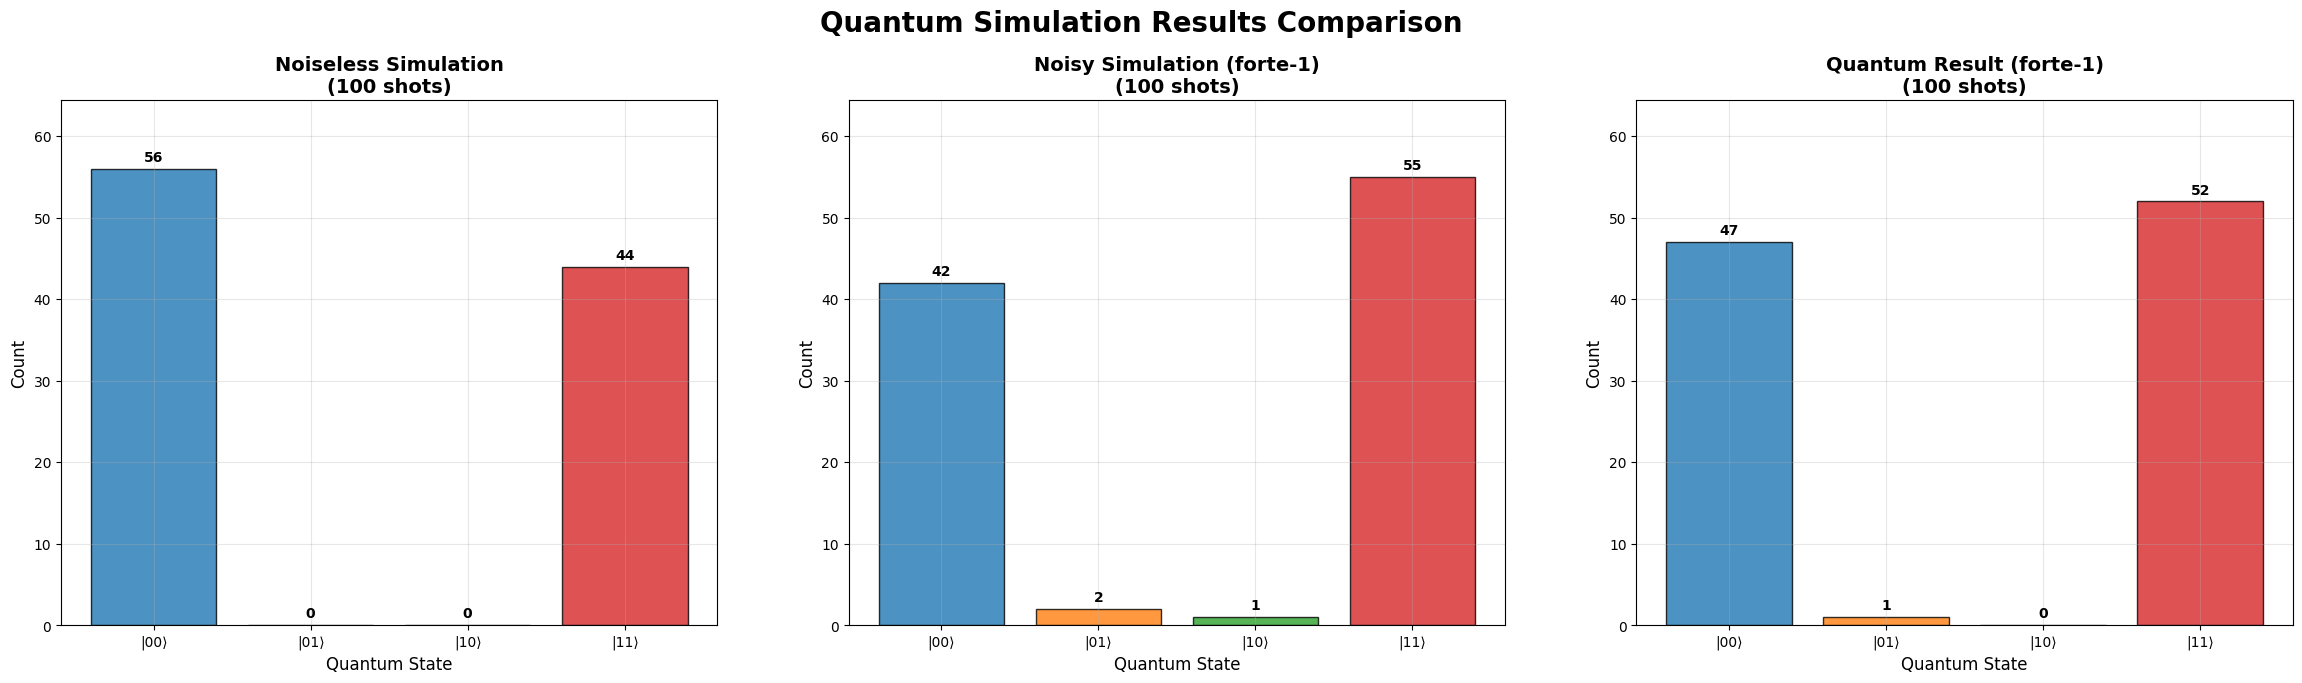

In [6]:
# Plotting of results

print("\n✅ Comparison and Plotting of Results")
data = {}
for name in ['noiseless', 'noisy', 'quantum']:
    with open(f'{name}_result.pkl', 'rb') as f:
        result = pickle.load(f)
        data[name] = result.histogram(key='x')

# Create comparison DataFrame
states = range(4)
comparison_df = pd.DataFrame({
    'State': states,
    'Binary': [format(s, '02b') for s in states],
    'Noiseless': [data['noiseless'].get(s, 0) for s in states],
    'Noisy': [data['noisy'].get(s, 0) for s in states],
    'Quantum': [data['quantum'].get(s, 0) for s in states]
})

print(comparison_df.to_string(index=False))
print("="*50 + "\n")

# Plotting
fig = plt.figure(figsize=(24, 7))
fig.suptitle('Quantum Simulation Results Comparison', fontsize=20, fontweight='bold', y=0.98)

state_labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plot_configs = [
    (1, 'Noiseless', 'Noiseless Simulation\n(100 shots)'),
    (2, 'Noisy', 'Noisy Simulation (forte-1)\n(100 shots)'),
    (3, 'Quantum', 'Quantum Result (forte-1)\n(100 shots)')
]

max_count = comparison_df[['Noiseless', 'Noisy', 'Quantum']].max().max()

# Individual plots
for idx, col, title in plot_configs:
    ax = plt.subplot(1, 3, idx)
    bars = ax.bar(state_labels, comparison_df[col], color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xlabel('Quantum State', fontsize=12)
    ax.set_ylim(0, max_count * 1.15)
    ax.grid(True, alpha=0.3)

    # Add count labels
    for bar, count in zip(bars, comparison_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_count*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.subplots_adjust(left=0.05, bottom=0.1, right=0.98, top=0.85, wspace=0.2)
plt.show()

In [ ]:
# IBM libraries
!pip install qiskit qiskit-ibm-runtime qiskit[visualization] -q
import matplotlib.pyplot as plt
import numpy as np
import qiskit
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from IPython.display import display, Markdown

In [ ]:
# Connect to IBM backend
print("✅ Connect to IBM Quantum")
api_token = userdata.get('ibm-quantum')
service = QiskitRuntimeService(channel='ibm_quantum_platform', token=api_token)


print("\n✅ List of all backends")
available_backends = service.backends()
print("Available Quantum Backends:")
for b in available_backends:
    print(f"- {b.name} ({b.num_qubits} qubits)")

print("\n✅ Select quantum backend")
backend = service.backend('ibm_strasbourg')
# backend = service.least_busy(simulator=False, operational=True) # Choose automatically
print(f"Selected backend: {backend.name}")

#print("\n✅ Documentation")
#display(Markdown(r"Devices: https://eu-de.quantum.cloud.ibm.com/computers"))
#display(Markdown(r"Topology: https://eu-de.quantum.cloud.ibm.com/docs/de/guides/qpu-information"))
#display(Markdown(r"Jobs: https://eu-de.quantum.cloud.ibm.com/workloads"))
#display(Markdown(r"Cost: https://cloud.ibm.com/billing"))
#display(Markdown(r"Tutorials: https://eu-de.quantum.cloud.ibm.com/docs/de/tutorials"))

In [ ]:
# IBM Circuit Definition

# Task
print("\n✅ Create unequal superposition (non-uniform probability distributions) with rotation gates Rᵧ(π3)")
display(Markdown(r"* Final State: $|\psi_{final}\rangle = \frac{\sqrt{3}}{2\sqrt{2}}|1000\rangle + \frac{\sqrt{3}}{2\sqrt{2}}|1010\rangle + \frac{1}{2\sqrt{2}}|1101\rangle + \frac{1}{2\sqrt{2}}|1111\rangle$"))
display(Markdown(r"* Probabilities ($P = |\text{amplitude}|^2$):: $|1000\rangle, |1010\rangle$: $P = |\frac{\sqrt{3}}{2\sqrt{2}}|^2 = 3/8 = \textbf{37.5\%}$ and $|1101\rangle, |1111\rangle$: $P = |\frac{1}{2\sqrt{2}}|^2 = 1/8 = \textbf{12.5\%}$"))

print("\n✅ Create the Quantum Circuit with Asymmetric State Evolution (with Unequal Superposition)")
qc = QuantumCircuit(4, 4)
qc.ry(np.pi / 3, 0) # Replace H(0) with Ry(pi/3, 0) to create a 75%/25% split
qc.h(1)             # Keep the H on q1 for a 50/50 split
qc.barrier()
qc.cx(0, 2)
qc.x(3)
qc.barrier()
qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
#print("\nIdeal Circuit Diagram:")
display(qc.draw("mpl"))

In [ ]:
# IBM Circuit Transpilation
print(f"\n✅ Transpiled Circuit for Backend {backend.name} (translates ideal circuit into one the hardware can run)")
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
#print(f"\nTranspiled Circuit for {backend.name}:")
display(isa_circuit.draw("mpl"))

In [ ]:
#  IBM Simulation

# ----- Local Simulation ----
print("\n✅ Run local simulation")
from qiskit.primitives import StatevectorSampler as LocalSampler
from qiskit.visualization import plot_histogram

local_sampler = LocalSampler() # Create local sampler
local_shots = 1024
local_job = local_sampler.run(pubs=[(qc,)], shots=local_shots) # Run circuit
local_result = local_job.result()
local_counts = local_result[0].data.c.get_counts() # Extract counts from result
print(f"Local Simulation results (counts) with {local_shots} shots:")
print(local_counts)
print("\nProbabilities:")
for bitstring, count in sorted(local_counts.items()):
    probability = count / local_shots
    print(f"  |{bitstring}>: {probability:.3f} ({count}/{local_shots})")

display(plot_histogram(local_counts, title="Local Simulation Results"))


✅ Run job on IBM quantum computer

Submitting job to ibm_strasbourg...
Job submitted successfully! Job ID: d7m5ig0h39qs73djvnd0

✅ Job Status
QUEUED

✅ Job metrics
{'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.46.1,qiskit-2.4.1*', 'timestamps': {'created': '2026-04-25T06:03:44.833181Z', 'finished': None, 'running': None}, 'bss': {'seconds': 0}, 'usage': {'quantum_seconds': 0, 'seconds': 0}}

✅ Job result
PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=4>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-04-25 06:03:48', stop='2026-04-25 06:03:48', size=1024>)])}, 'version': 2})

✅ Get and display results

Measurement Results (Counts):
{'1011': 7, '1000': 401, '1111': 126, '1010': 354, '1101': 113, '1001': 4, '1100': 5, '0000': 7, '0101': 2, '0010': 2, '0111': 1, '1110': 2}


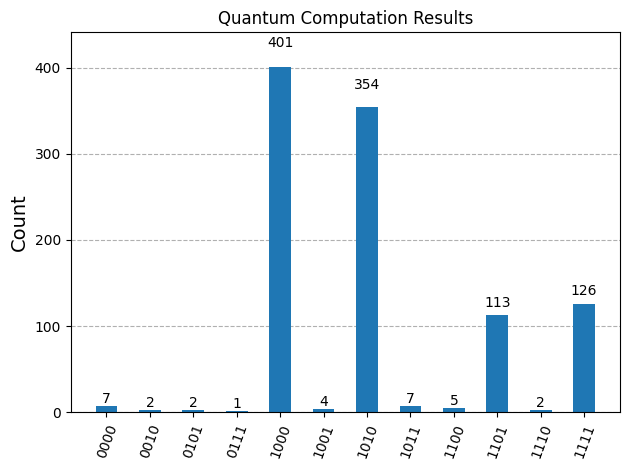

In [ ]:
# IBM Quantum Computation ⚠️

print("\n✅ Run job on IBM quantum computer")
sampler = Sampler(mode=backend)
shots = 1024
print(f"\nSubmitting job to {backend.name}...")
job = sampler.run(pubs=[(isa_circuit,)], shots=shots) # Run transpiled 'isa_circuit', not original 'qc'
print(f"Job submitted successfully! Job ID: {job.job_id()}")

print("\n✅ Job Status")
print(f"{job.status()}")

print("\n✅ Job metrics")
print(f"{job.metrics()}")

print("\n✅ Job result")
print(f"{job.result()}")

print("\n✅ Get and display results")
result = job.result()
counts = result[0].data.c.get_counts()
print("\nMeasurement Results (Counts):")
print(counts)
plot_histogram(counts)

display(plot_histogram(counts, title="Quantum Computation Results"))

In [ ]:
!pip install cirq openfermion -q
import cirq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Scheduling execution on the Quantum Engine...

View jobs at: https://console.cloud.google.com/quantum/jobs?project=deltorobarba-sandbox-30879

Counter({1: 995, 0: 5})
     result
0         1
1         1
2         1
3         1
4         1
..      ...
995       1
996       1
997       1
998       1
999       1

[1000 rows x 1 columns]
Job ID: job-CVWNGQ4M7UEDCKS1260330-144117


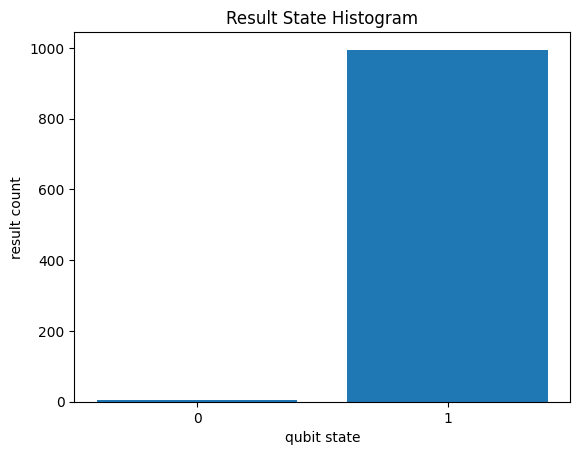

In [ ]:
# Google Quantum

# https://quantumai.google/cirq/google/engine
# https://quantumai.google/cirq/tutorials/google/start


# Google Libraries
!pip install cirq cirq_google qsimcirq -q
import cirq
import cirq_google
import cirq_google as cg

print(f"Cirq version: {cirq.__version__}")
print(f"Cirq-IonQ version: {cirq_ionq.__version__}")
print(f"Qiskit version: {qiskit.__version__}")

project_id='deltorobarba-sandbox-30879'

# Create a Quantum Engine client
engine = cg.Engine(project_id='deltorobarba-sandbox-30879')

# List of virtual processors (noisy and noiseless simulation)
# https://quantumai.google/reference/python/cirq_google/engine/list_virtual_processors
cirq_google.engine.list_virtual_processors() # -> list[str]

"""
Approved users have access to a processor in "open-swim" mode that runs jobs on a first-in-first-out basis per user, with a fairness
algorithm that balances jobs across users. To see which processors you have access to, you can either visit the Cloud Console or call
list_processors() on an Engine object.
"""

print("\n✅ Show all quantum processors")
# https://quantumai.google/reference/python/cirq_google/engine/list_virtual_processors
allprocessors = engine.list_processors()
print(f"Available processors: {allprocessors}")


print("\n✅ Show available quantum processors")
# https://pantheon.corp.google.com/quantum/processors?e=13802955&mods=local_coliseum&project=deltorobarba-sandbox-30879
processors = [p.processor_id for p in engine.list_processors() if p.health() == 'OK']
print(f"Available processors: {processors}")

print("\n✅ Select quantum hardware processor")
#processor_id = 'WLA1HHPR00V07_5A_CANYON'
processor_id = 'WLA1HHPR00V02_4A_PINK'
print(f"Chosen quantum chip: {processor_id}")

print("\n✅ Show chip topology (qubit connectivity)")
id = processor_id or processors[0]
processor = engine.get_processor(id)
device = processor.get_device()
print(device)

print("\n✅ Verify which gates processor supports")
device = processor.get_device()
print(device.metadata.gateset)
print(len(device.metadata.nx_graph.edges), "live edges")


#########
# @title Google Circuit, Transpilation and Simulation
#========================================

print("\n✅ Define a qubit at an arbitrary grid location")
qubit = cirq.GridQubit(0, 0)

# Create a circuit (qubits start in the |0> state).
circuit = cirq.Circuit(
    cirq.X(qubit),                     # NOT gate
    cirq.measure(qubit, key='result')  # Measurement
)

print("Circuit:")
print(circuit)


"""
# Create another single qubit sample circuit

qubit = cirq.GridQubit(5, 2)
circuit = cirq.Circuit(
    cirq.X(qubit)**0.5,                 # Square root of NOT.
    cirq.measure(qubit, key='result')   # Measurement.
)

print("Circuit:")
print(circuit)



# Create another two-qubit sample circuit


q0, q1 = cirq.GridQubit(0, 0), cirq.GridQubit(0, 1)

circuit = cirq.Circuit(
    cirq.H(q0),             # Put q0 in superposition
    cirq.CZ(q0, q1),        # <--- THIS is a two-qubit gate (Controlled-Z)
    cirq.measure(q0, q1, key='result')
)
"""

print("\n✅ Circuit Transpilation: Transform circuit to use an available hardware qubit")
  # Show hardware circuit (Verify Code!)
valid_qubit = sorted(device.metadata.qubit_set)[0]

  # Transform circuit to use an available hardware qubit.
hw_circuit = circuit.transform_qubits(lambda q: valid_qubit)

print(hw_circuit)

print("\n✅ Best practice 1: Map Circuit onto Grid when using more than one qubit")

  # If your circuit uses more than one qubit, you can map the circuit onto the grid
  # of the quantum processor in a way that accounts for its topology.

device_graph = device.metadata.nx_graph
router = cirq.RouteCQC(device_graph)
hw_circuit = router(circuit)
print(hw_circuit)

print("\n✅ Best practice 2: Transform circuit into gateset calibrated for quantum chip")

  # Second, if your quantum processor is calibrated to do a specific set of gates,
  # you will need to transform your circuit into that gateset. For example, for a CZ gateset, you can do following.

gateset = cirq.CZTargetGateset(allow_partial_czs=True)
transformed_circuit = cirq.optimize_for_target_gateset(hw_circuit, gateset=gateset)
print(transformed_circuit)

# Other gatesets and considerations are included in the best practices guide:
# https://quantumai.google/cirq/google/best_practices


print("\n✅ Simulate the circuit, repeating n times")
print("Simulating circuit using Cirq...\n")
results = cirq.sample(circuit, repetitions=100)
print("Measurement results:")
print(results)


#######

#  Google Quantum Computation ⚠️
#========================================

print("Scheduling execution on the Quantum Engine...\n")
print("View jobs at: https://console.cloud.google.com/quantum/jobs?project={}\n".format(project_id))

# Create an Engine object
engine = cg.Engine(project_id='deltorobarba-sandbox-30879')

# Create sampler from engine
sampler = engine.get_sampler(processor_id=processor_id) # or: sampler = processor.get_sampler()

# Run circuit on quantum engine
results = sampler.run(transformed_circuit,
                      repetitions=1000) # changed circuit
# Return results
cirq.plot_state_histogram(results)
print(results.histogram(key='result'))  # Histogram
print(results.data)                     # Data itself

# Print Job ID
print(f"Job ID: {results.job_id}")